In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
# Imports
import torch
import pandas as pd
import os 
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import chisquare, ks_2samp
from pathlib import Path
import itertools

from vae import GroupHardMax
from finetuner import get_matching_indices


In [2]:
# Functions
def rmse(arr1, arr2):
    return np.sqrt(((arr1 - arr2)**2).sum()/len(arr1))

def kl(arr1, arr2):
    if np.any((arr1 > 0) & (arr2 == 0)):
        return np.inf

    convention_mask  = ~((arr1==0) & (arr2!=0)) # Ensures contributions of 0 for 0log(0)
    return np.sum(arr1[convention_mask]*np.log(arr1[convention_mask]/arr2[convention_mask]))

def plot_vars_bars(marginals, predicted_marginals, state_marginals, variables, legend=False, figsize= (10,5), bbox_to_anchor = (1,1), img_name = None):
    num_keys_per_variable = []
    num_keys = 0
    for v in variables:
        # Count how many keys match v
        keys_v = [k for k in predicted_marginals.keys() if k.startswith(v)]
        num_keys_per_variable.append(len(keys_v))
        num_keys += len(keys_v)

    fig = plt.figure(figsize=figsize)  # Overall size; adjust as needed

    # Create a 1-row, len(variables)-column grid,
    # with column widths proportional to the number of categories
    gs = GridSpec(1, len(variables), width_ratios=num_keys_per_variable, wspace=0.2)

    axes = []
    for i in range(len(variables)):
        if i == 0:
            ax = fig.add_subplot(gs[i])  # first subplot
        else:
            ax = fig.add_subplot(gs[i])
            ax.sharey(axes[0])          # share y-axis with first subplot
        axes.append(ax)

    for i, v in enumerate(variables):
        ax = axes[i]
        
        # Get keys & data
        keys = [k for k in marginals.keys() if k.startswith(v)]
        state_marginals_v = [state_marginals[k] for k in keys]
        pred_marginals_v  = [predicted_marginals[k] for k in keys]
        gt_marginals_v    = [marginals[k] for k in keys]

        # Renormalise marginals due to small numerical imprecision
        pred_marginals_v = [m/sum(pred_marginals_v) for m in pred_marginals_v]
        gt_marginals_v = [m/sum(gt_marginals_v) for m in gt_marginals_v]
        state_marginals_v = [m/sum(state_marginals_v) for m in state_marginals_v]

        # Calculate chi square p value
        if v == 'HHL':
            # Get rid of 'other' category, renormalise
            pred_marginals_sub = pred_marginals_v[:-1]
            gt_marginals_sub = gt_marginals_v[:-1]
            state_marginals_sub = state_marginals_v[:-1]

            pred_marginals_sub = [m/sum(pred_marginals_sub) for m in pred_marginals_sub]
            gt_marginals_sub = [m/sum(gt_marginals_sub) for m in gt_marginals_sub]
            state_marginals_sub = [m/sum(state_marginals_sub) for m in state_marginals_sub]

            _, p_tract = chisquare(pred_marginals_sub, gt_marginals_sub)
            _, p_state = chisquare(state_marginals_sub, gt_marginals_sub)
        else:
            _, p_tract = chisquare(pred_marginals_v, gt_marginals_v)
            _, p_state = chisquare(state_marginals_v, gt_marginals_v)

        # Positions for bars
        x = np.arange(len(keys))
        width = 0.2

        # Plot grouped bars
        axes[i].bar(x,                 state_marginals_v, width=width, label='State Marginals')
        axes[i].bar(x + width,         pred_marginals_v,  width=width, label='Synthetic Marginals')
        axes[i].bar(x + 2 * width,     gt_marginals_v,    width=width, label='Groundtruth Marginals')

        # Plot p value
        if v == 'HHL':
            ax.text(0.99, 0.99, f'P_t = {p_tract:.2f} (Excluding Other)\nP_s = {p_state:.2f} (Excluding Other)', transform=ax.transAxes, 
                horizontalalignment='right', verticalalignment='top', fontsize=10, color='black')
        else:
            ax.text(0.99, 0.99, f'P_t = {p_tract:.2f}\nP_s = {p_state:.2f}', transform=ax.transAxes, 
                horizontalalignment='right', verticalalignment='top', fontsize=10, color='black')

        # Nicely align ticks
        axes[i].set_xticks(x + width)
        axes[i].set_xticklabels([k.removeprefix(v + ':') for k in keys], rotation=90)

        # Give the bars a bit of left-right padding
        axes[i].set_xlim([-0.5, len(keys)])

        axes[i].set_title(variables_dict[v])

    if legend:
        fig.legend(*axes[0].get_legend_handles_labels(),
            loc='upper right', bbox_to_anchor=bbox_to_anchor)

    plt.tight_layout()
    if img_name:
        plt.savefig(f'/workspace/finetune_pngs_dfs/{img_name}', bbox_inches = 'tight')
    plt.show()

def get_marginals(data_table, household_indices, personal_indices, nan_indices):
    n_households = data_table.shape[0]

    marginals = {}
    # Handle household variables
    for var, indices in household_indices.items():
        marginals[var] = data_table[:, indices].mean()

    # Handle personal variables
    n_people_per_household = len(list(personal_indices.values())[0])
    n_people_with_nans = n_people_per_household * n_households

    for var, indices in personal_indices.items():
        matching_nan_variable = var.split(":")[0] + ':' + 'nan' # Eg for SEX:male, matching nan variable is SEX:nan
        n_people = n_people_with_nans - data_table[:, nan_indices[matching_nan_variable]].sum()
        marginals[var] = data_table[:, indices].sum()/n_people

    return marginals

def create_table(marginals, predicted_marginals, state_marginals, file_name):
    RMSEs_baseline = {}
    RMSEs_synth = {}
    KLs_baseline = {}
    KLs_synth = {}

    variables = ['TEN', 'VEH', 'HHL', 'HINCP', 'R18', 'R65', 'AGEP', 'SCHL', 'SEX']
    for v in variables:
        # Get data
        keys = [k for k in marginals.keys() if k.startswith(v)]
        state_marginals_v = [state_marginals    [k] for k in keys]
        pred_marginals_v  = [predicted_marginals[k] for k in keys]
        gt_marginals_v    = [marginals[k] for k in keys]

        # Renormalise marginals due to small numerical imprecision
        pred_marginals_v = np.array([m/sum(pred_marginals_v) for m in pred_marginals_v])
        gt_marginals_v = np.array([m/sum(gt_marginals_v) for m in gt_marginals_v])
        state_marginals_v = np.array([m/sum(state_marginals_v) for m in state_marginals_v])

        if v == 'HHL':
            # Get rid of 'other' category, renormalise
            pred_marginals_v = pred_marginals_v[:-1]
            gt_marginals_v = gt_marginals_v[:-1]
            state_marginals_v = state_marginals_v[:-1]

            pred_marginals_v /= pred_marginals_v.sum()
            gt_marginals_v /= gt_marginals_v.sum()
            state_marginals_v /= state_marginals_v.sum()

        RMSEs_baseline[v] = rmse(state_marginals_v, gt_marginals_v)
        RMSEs_synth[v] = rmse(pred_marginals_v, gt_marginals_v)
        KLs_baseline[v] = kl(state_marginals_v, gt_marginals_v)
        KLs_synth[v] = kl(pred_marginals_v, gt_marginals_v)

    table = pd.DataFrame([RMSEs_baseline, RMSEs_synth, KLs_baseline, KLs_synth], index = ['RMSE Baseline', 'RMSE Syn. HI.', 'KL Baseline', 'KL Syn. HI.'])
    table.to_csv(f'/workspace/finetune_pngs_dfs/{file_name}.csv')
    return table


In [3]:
# Useful variables

group_sizes = [
    2,    5,    5,    11,    2,    2,    3,    3,    3,    3,    3,    3,    3,    3,    3,    3,    3,    3,    3,    3,    19,    19,    19,    19,    19,    19,    19,    19,    19,    19,    19,    19,    19,    19,    7,    7,    7,    7,    7,    7,    7,    7,    7,    7,    7,    7,    7,    7,]

variables_dict = {
    'TEN': 'Tenure',
    'HHL': 'Household Language',
    'VEH': 'Vehicles avaiable',
    'HINCP': 'Household Income (Thousands of USD)',
    'AGEP': 'Age (in years)',
    'SEX': 'Sex',
    'R65': 'Persons 65 years ≤',
    'R18': 'Persons ≤18 years',
    'SCHL': 'Education',
}

# Data Handling

In [4]:
# Choose model
model_names = [m for m in os.listdir('/workspace/finetuned_models/predictions') if 'north' not in m]
model_names.sort()
print(model_names)
model_name = 'finetuned_model_l25_h750_b2_g2_y21_final_1436.pth'

['finetuned_model_l25_h750_b2_g2_y21_final_100.pth', 'finetuned_model_l25_h750_b2_g2_y21_final_1000.pth', 'finetuned_model_l25_h750_b2_g2_y21_final_1436.pth', 'finetuned_model_l25_h750_b2_g2_y21_final_1_1_1.pth', 'finetuned_model_l25_h750_b2_g2_y21_final_1_1_10.pth', 'finetuned_model_l25_h750_b2_g2_y21_final_1_1_100.pth', 'finetuned_model_l25_h750_b2_g2_y21_final_1_25_2.pth', 'finetuned_model_l25_h750_b2_g2_y21_final_200.pth', 'finetuned_model_l25_h750_b2_g2_y21_final_50.pth', 'finetuned_model_l25_h750_b2_g2_y21_final_500.pth']


In [5]:
# Read state data
# Get del_pums_data and marginals
data_name = "one_hot_pNaNs_agep_21.csv"
pums_data = pd.read_csv(f"/workspace/data/{data_name}")
pums_np = pums_data.to_numpy()

# Read marginals
with open("/workspace/data/ACS_tract_tables/Delaware50101/marginals.json") as f:
    marginals = json.load(f)

# Read predictions data and make one-hot
prediction_folder = '/workspace/finetuned_models/predictions/' # Get path

prediction_paths = os.listdir(prediction_folder)
prediction_path = prediction_folder + model_name

predictions_torch = torch.load(prediction_path, map_location=torch.device('cpu') ) # Load
predictions_unchanged = predictions_torch.detach().numpy()


hardmax = GroupHardMax(group_sizes) # Make one-hot
predictions_onehot = hardmax(predictions_torch)
synth_data = predictions_onehot.detach().numpy()

# Get marginals for predicted, predicted_cheating and state data
household_indices, personal_indices, nan_indices = get_matching_indices(marginals, list(pums_data.columns))

# Get marginal values for the predictions:
predicted_marginals         = get_marginals(synth_data, household_indices, personal_indices, nan_indices)
predicted_marginals_cheat   = get_marginals(predictions_unchanged, household_indices, personal_indices, nan_indices)
state_marginals             = get_marginals(pums_np, household_indices, personal_indices, nan_indices)

# Create dir for results
os.makedirs('/workspace/finetune_pngs_dfs', exist_ok = True)

In [6]:
# prepare dicts and namings for plotting
labels = list(pums_data.columns)
labels = [label.split(":") for label in labels]
feature_label_dict = {}
for key, label in labels:
    if key in feature_label_dict:
        feature_label_dict[key].append(label) 
    else:
        feature_label_dict[key] = [label]

indices = {}

for key, label in labels:
    if key in indices:
        indices[key].append(pums_data.columns.get_loc(f"{key}:{label}"))
    else:
        indices[key] = [pums_data.columns.get_loc(f"{key}:{label}")]

ten_dict = {key: [] for key in feature_label_dict['TEN']}
hhl_dict = {key: [] for key in feature_label_dict['HHL']}
veh_dict = {key: [] for key in feature_label_dict['VEH']}
hincp_dict = {key: [] for key in feature_label_dict['HINCP']}
sex_dict = {key: [] for key in feature_label_dict['SEX_1']}
education_dict = {key: [] for key in feature_label_dict['SCHL_1']}
age_dict = {key: [] for key in feature_label_dict['AGEP_1']}
r18_dict = {key: [] for key in feature_label_dict['R18']}
r65_dict = {key: [] for key in feature_label_dict['R65']}

# create dicts for the groups and their indices 
for key, labels in feature_label_dict.items():
    if 'SEX' in key:
        for idx, label in enumerate(labels):
            sex_dict[label].append(indices[key][idx])
    elif 'SCHL' in key:
        for idx, label in enumerate(labels):
            education_dict[label].append(indices[key][idx])
    elif 'AGEP' in key:
        for idx, label in enumerate(labels):
            age_dict[label].append(indices[key][idx])
    elif 'TEN' in key:
        for idx, label in enumerate(labels):
            ten_dict[label].append(indices[key][idx])
    elif 'HHL' in key:
        for idx, label in enumerate(labels):
            hhl_dict[label].append(indices[key][idx])
    elif 'VEH' in key:
        for idx, label in enumerate(labels):
            veh_dict[label].append(indices[key][idx])
    elif 'HINCP' in key:
        for idx, label in enumerate(labels):
            hincp_dict[label].append(indices[key][idx])
    elif 'R18' in key:
        for idx, label in enumerate(labels):
            r18_dict[label].append(indices[key][idx])
    elif 'R65' in key:
        for idx, label in enumerate(labels):
            r65_dict[label].append(indices[key][idx])


households = [ten_dict, hhl_dict, veh_dict, hincp_dict, r18_dict, r65_dict]
individuals = [sex_dict, education_dict, age_dict]


# Recreate Figure 10, table 4

/tmp/ipykernel_46340/2712987911.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


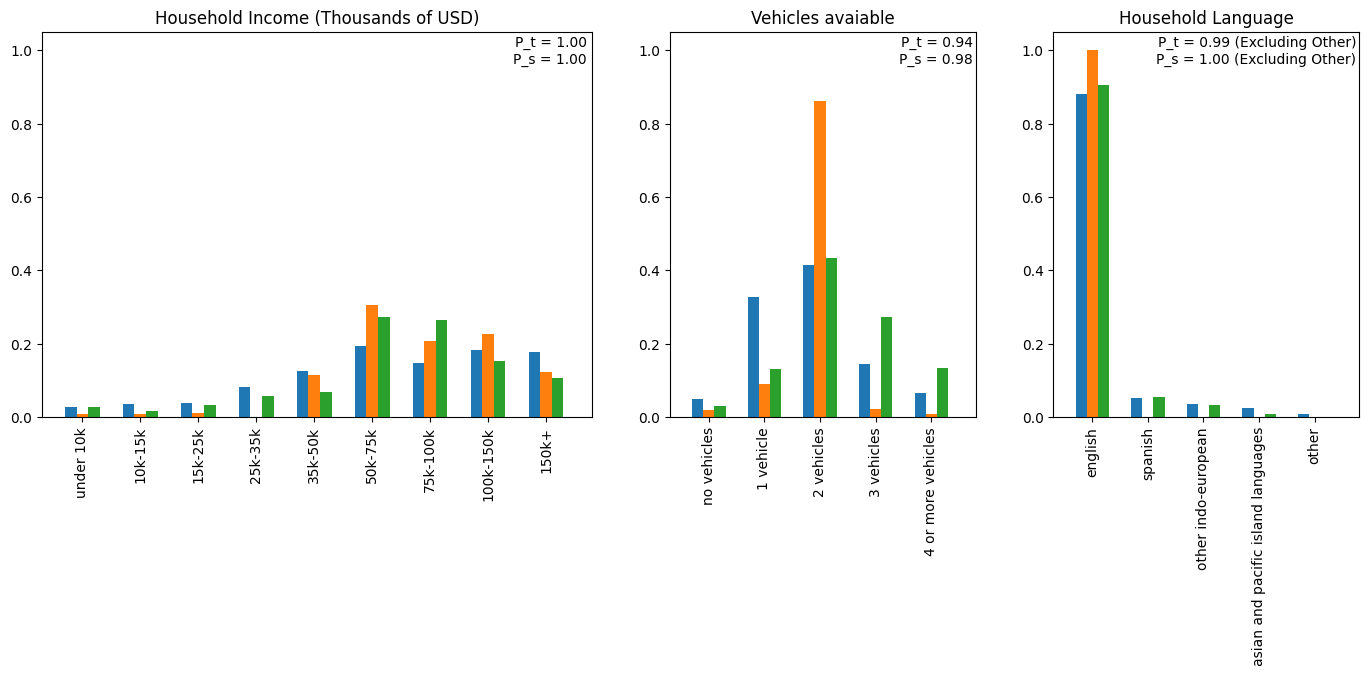

/tmp/ipykernel_46340/2712987911.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


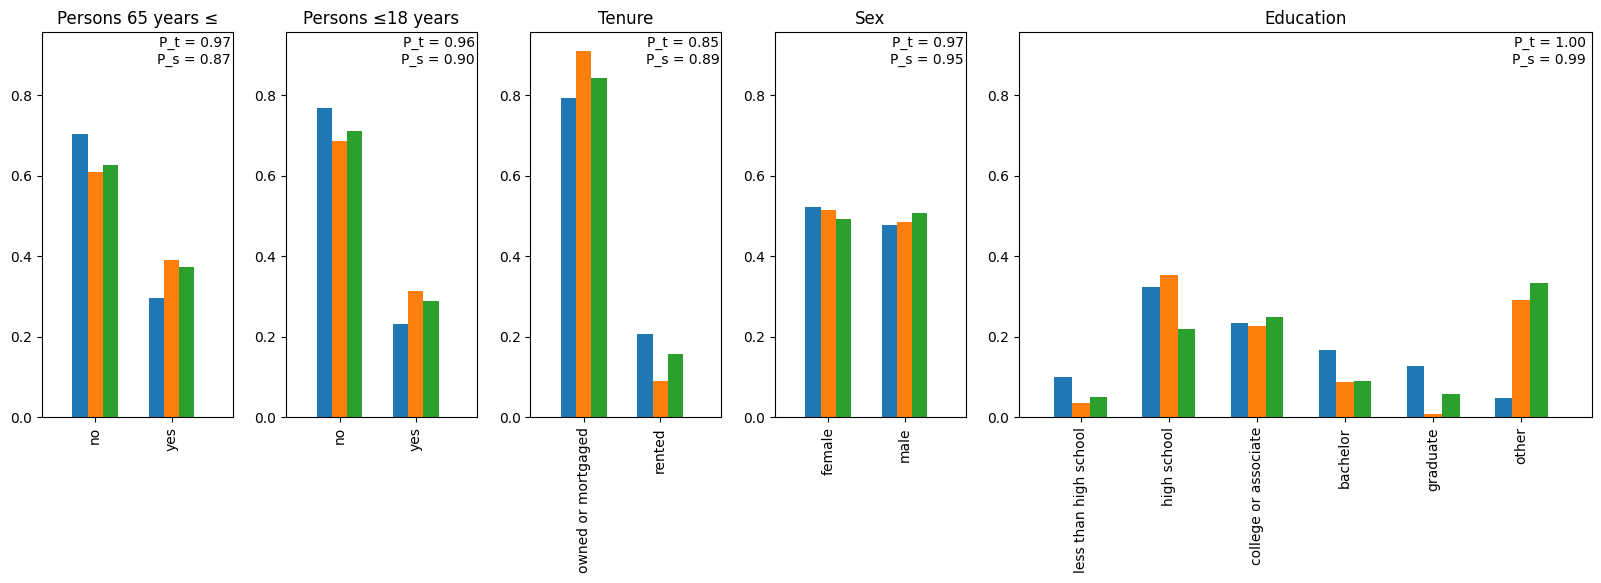

/tmp/ipykernel_46340/2712987911.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


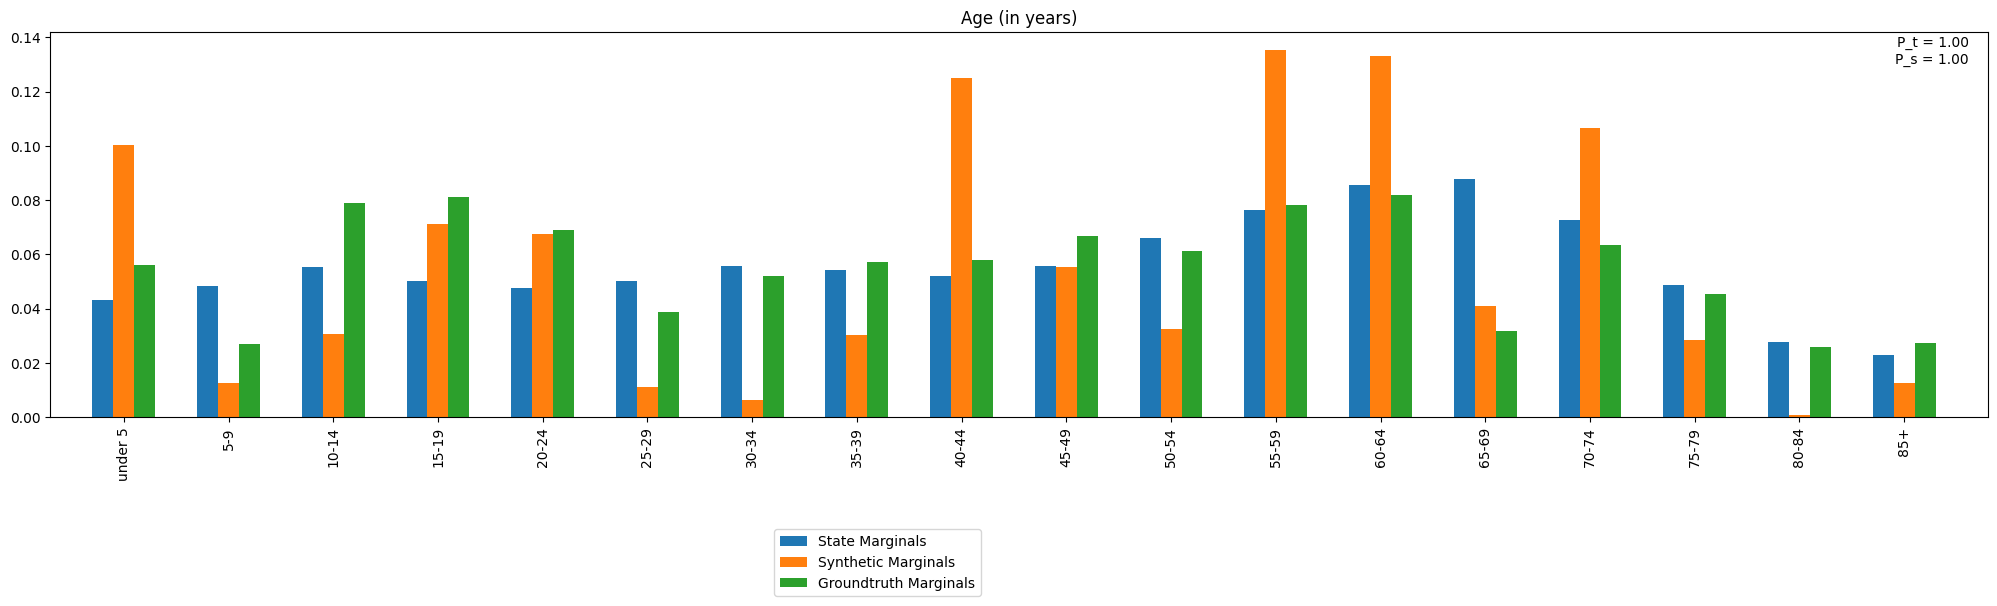

,TEN,VEH,HHL,HINCP,R18,R65,AGEP,SCHL,SEX
RMSE Baseline,0.049820,0.108794,0.012224,0.058259,0.057570,0.076221,0.018531,0.132293,0.028900
RMSE Syn. HI.,0.067167,0.228868,0.057054,0.042387,0.023677,0.018106,0.035498,0.061414,0.021465
KL Baseline,0.008682,0.164155,0.011582,0.097999,0.008415,0.012843,0.060321,0.288776,0.001671
KL Syn. HI.,0.019621,0.470614,0.099497,0.113435,0.001341,0.000697,0.207128,0.076247,0.000922


In [7]:
plot_vars_bars(marginals, predicted_marginals, state_marginals, ['HINCP', 'VEH', 'HHL'], legend=False, figsize = (17,5), img_name = 'dela_fig10_1')
plot_vars_bars(marginals, predicted_marginals, state_marginals, ['R65', 'R18', 'TEN', 'SEX', 'SCHL'], legend=False, figsize = (20,5), img_name = 'dela_fig10_2')
plot_vars_bars(marginals, predicted_marginals, state_marginals, ['AGEP'], legend=True, figsize = (25,5), bbox_to_anchor = (0.5, -0.1), img_name = 'dela_fig10_3')
create_table(marginals, predicted_marginals, state_marginals, 'table4')

## Recreate fig 10 and table 4 (cheating)

/tmp/ipykernel_46340/2712987911.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


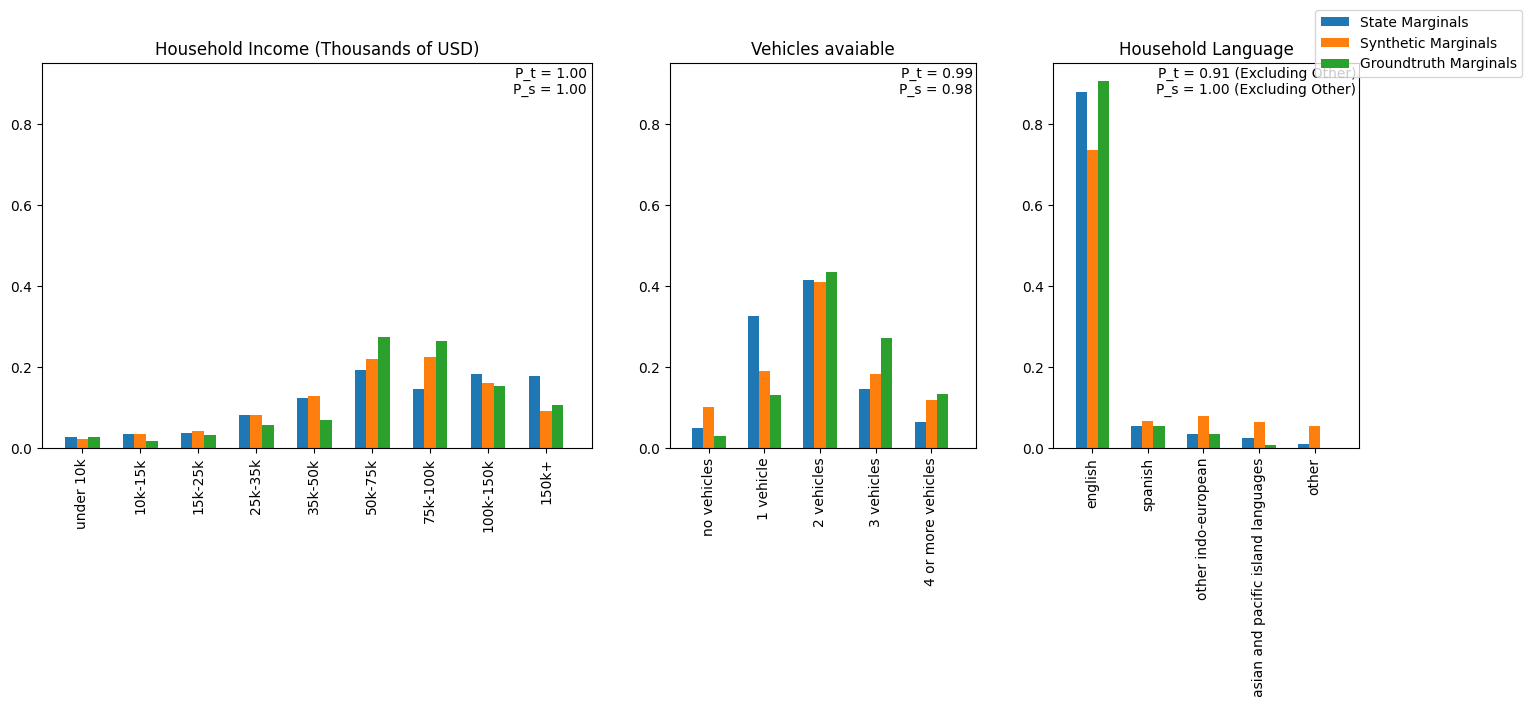

/tmp/ipykernel_46340/2712987911.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


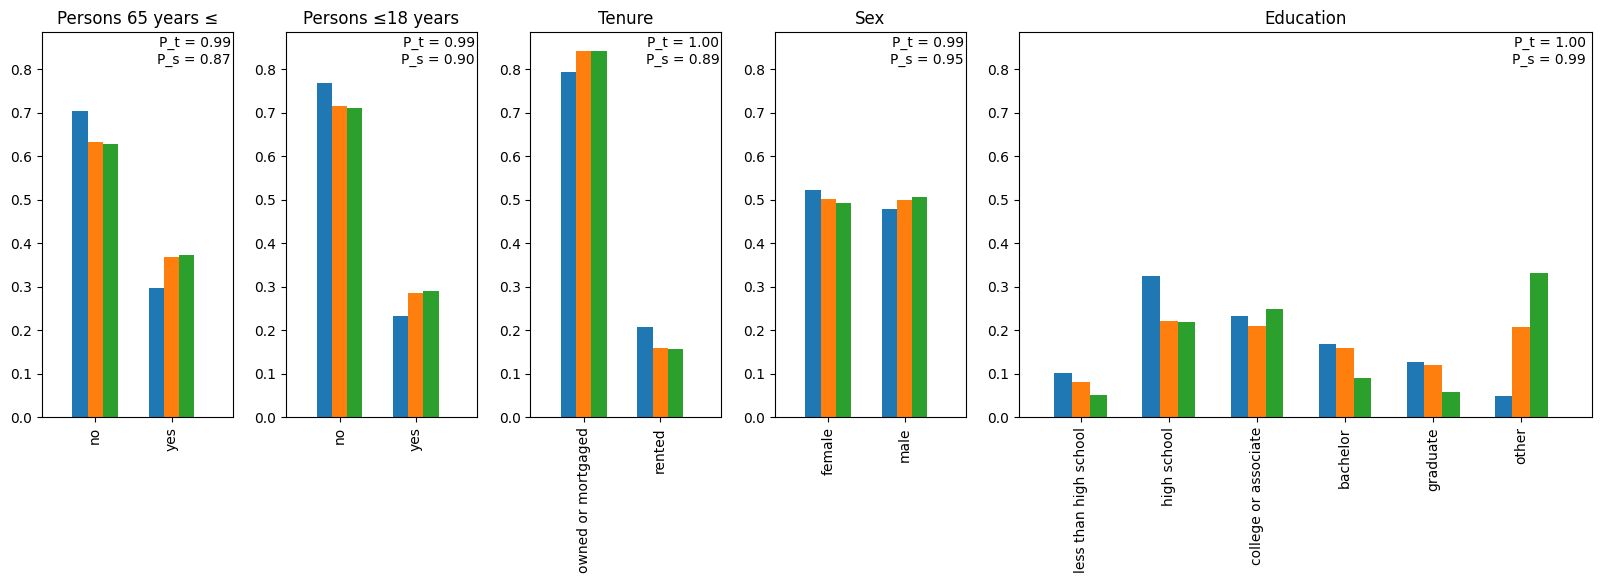

/tmp/ipykernel_46340/2712987911.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


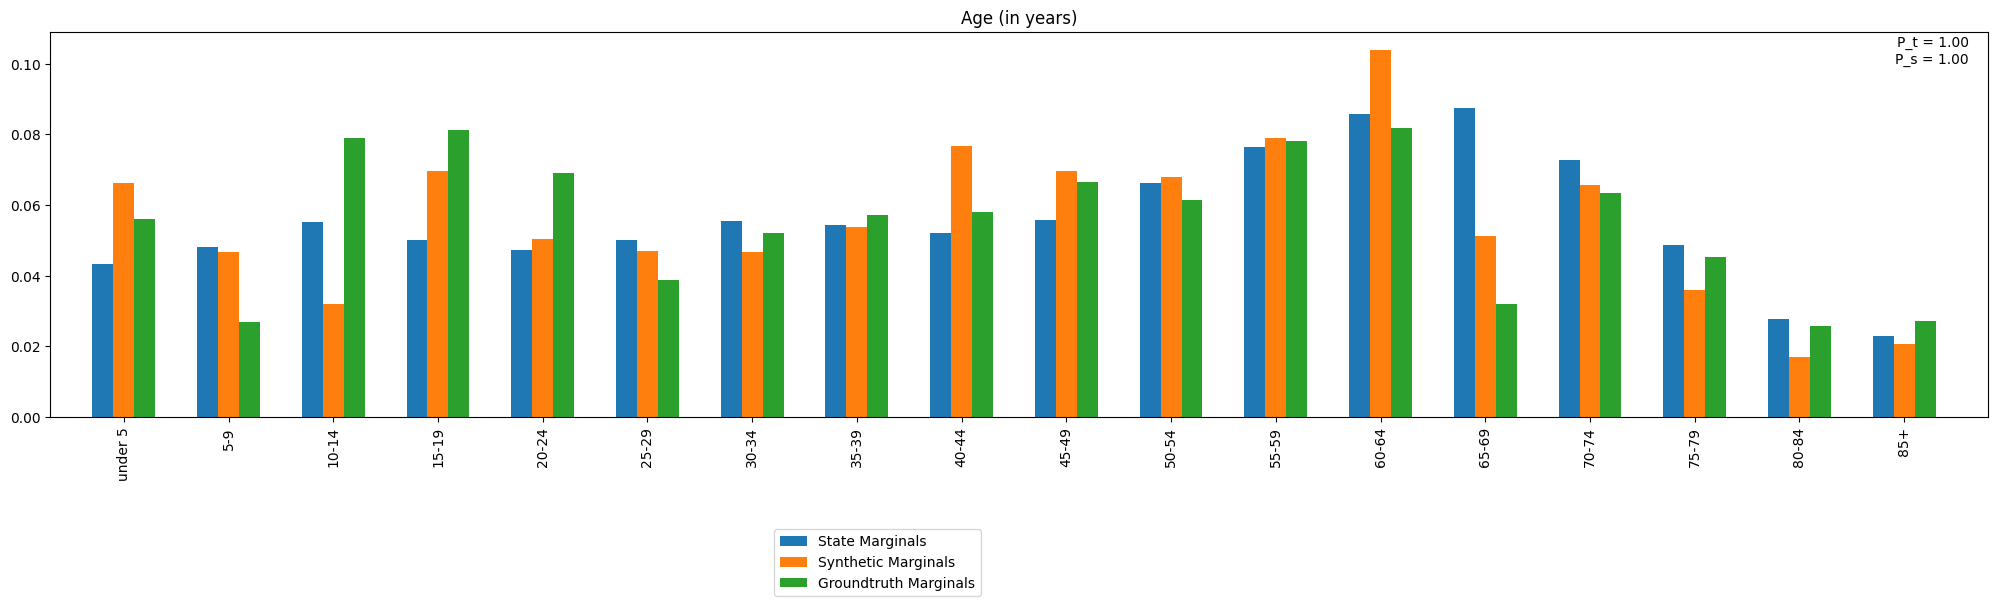

,TEN,VEH,HHL,HINCP,R18,R65,AGEP,SCHL,SEX
RMSE Baseline,0.049820,0.108794,0.012224,0.058259,0.057570,0.076221,0.018531,0.132293,0.028900
RMSE Syn. HI.,0.001745,0.059029,0.074669,0.032645,0.004763,0.004359,0.016239,0.066754,0.007809
KL Baseline,0.008682,0.164155,0.011582,0.097999,0.008415,0.012843,0.060321,0.288776,0.001671
KL Syn. HI.,0.000011,0.081580,0.123521,0.044770,0.000055,0.000041,0.043977,0.085161,0.000122


In [8]:
plot_vars_bars(marginals, predicted_marginals_cheat, state_marginals, ['HINCP', 'VEH', 'HHL'], legend=True, figsize = (17,5), img_name = 'dela_fig10_1_cheat')
plot_vars_bars(marginals, predicted_marginals_cheat, state_marginals, ['R65', 'R18', 'TEN', 'SEX', 'SCHL'], legend=False, figsize = (20,5), img_name = 'dela_fig10_2_cheat')
plot_vars_bars(marginals, predicted_marginals_cheat, state_marginals, ['AGEP'], legend=True, figsize = (25,5), bbox_to_anchor = (0.5, -0.1), img_name = 'dela_fig10_3_cheat')
create_table(marginals, predicted_marginals_cheat, state_marginals, 'table4_cheat')

## Recreate Figure 11 (non cheating and cheating)

In [9]:
# Choose model
model_names = [m for m in os.listdir('/workspace/finetuned_models/predictions') if 'north' in m]
model_names.sort()
print(model_names)
model_name = 'finetuned_north_carolina_best_1_1_10.pth'

['finetuned_north_carolina_best_1_1_1.pth', 'finetuned_north_carolina_best_1_1_10.pth', 'finetuned_north_carolina_best_1_1_100.pth', 'finetuned_north_carolina_best_1_25_2.pth']


In [10]:
data_name = 'north_carolina_21.csv'
nc_pums_data = pd.read_csv(f"/workspace/data/{data_name}")
nc_pums_np = nc_pums_data.to_numpy()


# Read marginals
with open("/workspace/data/ACS_tract_tables/NorthCarolina201/marginals.json") as f:
    nc_marginals = json.load(f)

# Read predictions data and make one-hot
prediction_folder = '/workspace/finetuned_models/predictions/' # Get path

prediction_paths = os.listdir(prediction_folder)
prediction_path = prediction_folder + model_name

predictions_torch_nc = torch.load(prediction_path, map_location=torch.device('cpu') ) # Load
predictions_unchanged_nc = predictions_torch_nc.detach().numpy()

# Get group sizes for nc

nc_pums_data.columns
prefixes = [v.split(':')[0] for v in nc_pums_data.columns]
nc_group_sizes = [len(list(group)) for _, group in itertools.groupby(prefixes)]

# Make predictions onehot
hardmax = GroupHardMax(nc_group_sizes) 
predictions_onehot_nc = hardmax(predictions_torch_nc)
synth_data_nc = predictions_onehot_nc.detach().numpy()

# Get marginals for predicted, predicted_cheating and state data
household_indices_nc, personal_indices_nc, nan_indices_nc = get_matching_indices(nc_marginals, list(nc_pums_data.columns))

# Get marginal values for the predictions:
predicted_marginals_nc         = get_marginals(synth_data_nc, household_indices_nc, personal_indices_nc, nan_indices_nc)
predicted_marginals_cheat_nc   = get_marginals(predictions_unchanged_nc, household_indices_nc, personal_indices_nc, nan_indices_nc)
state_marginals_nc             = get_marginals(nc_pums_np, household_indices_nc, personal_indices_nc, nan_indices_nc)

/tmp/ipykernel_46340/2712987911.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


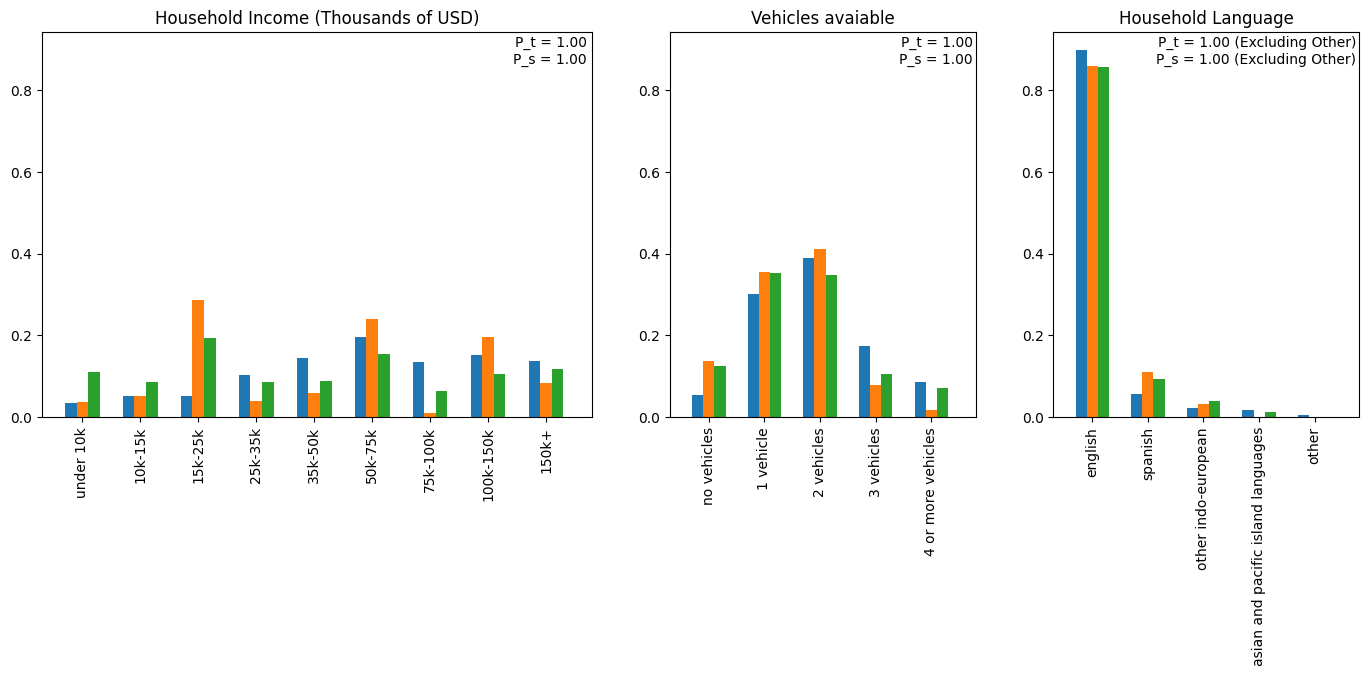

/tmp/ipykernel_46340/2712987911.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


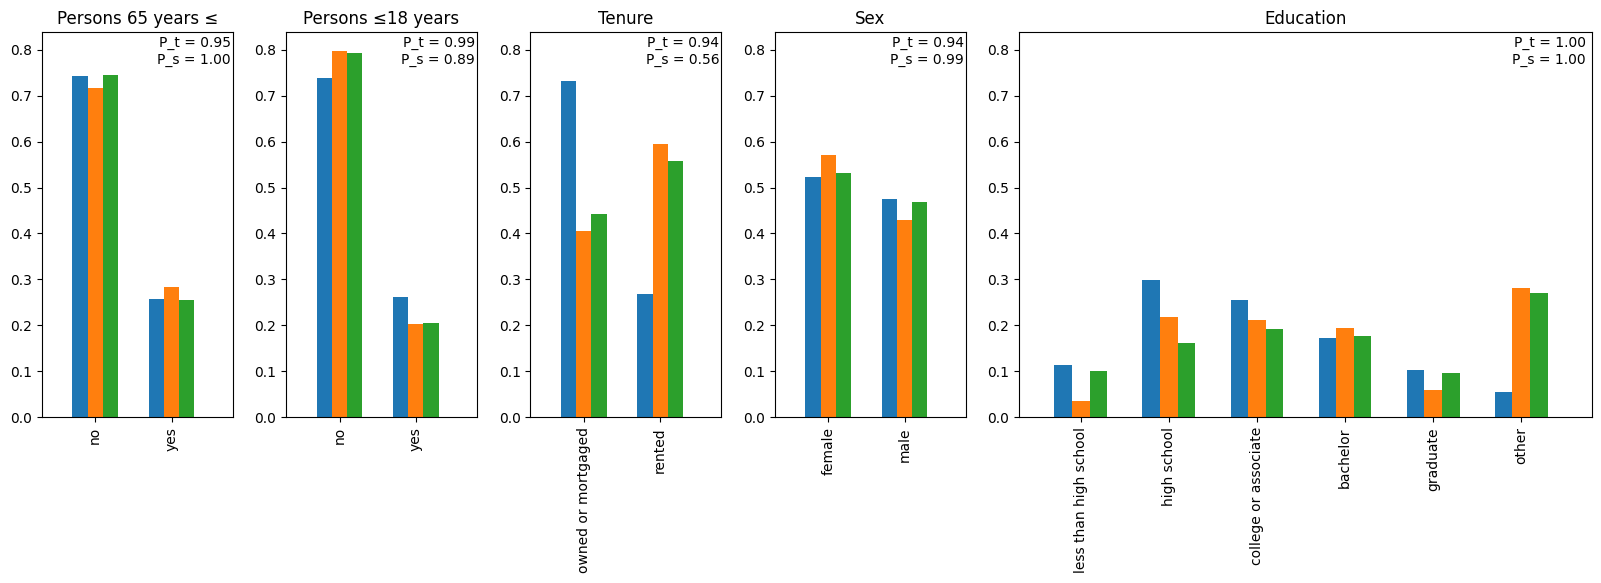

/tmp/ipykernel_46340/2712987911.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


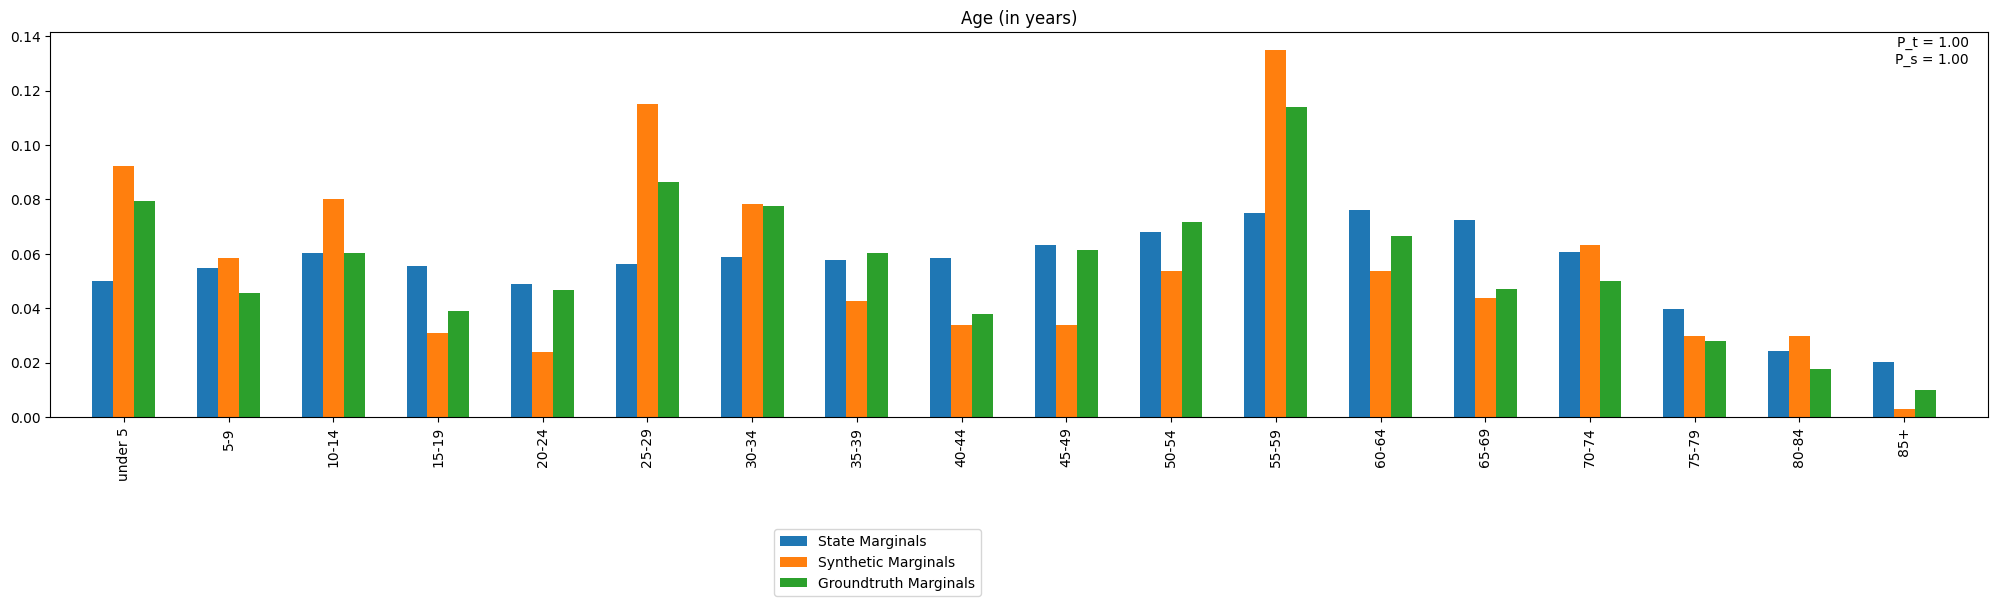

,TEN,VEH,HHL,HINCP,R18,R65,AGEP,SCHL,SEX
RMSE Baseline,0.288343,0.053276,0.031244,0.066434,0.055758,0.002225,0.017606,0.107475,0.008131
RMSE Syn. HI.,0.037000,0.039464,0.011113,0.064896,0.004234,0.028935,0.015921,0.040431,0.039121
KL Baseline,0.170746,0.051862,0.015225,0.180234,0.008943,0.000013,0.046174,0.183742,0.000133
KL Syn. HI.,0.002793,0.038663,0.014179,0.172975,0.000055,0.002152,0.042655,0.048659,0.003087


In [11]:
plot_vars_bars(nc_marginals, predicted_marginals_nc, state_marginals_nc, ['HINCP', 'VEH', 'HHL'], legend=False, figsize = (17,5), img_name = 'nc_fig10_1')
plot_vars_bars(nc_marginals, predicted_marginals_nc, state_marginals_nc, ['R65', 'R18', 'TEN', 'SEX', 'SCHL'], legend=False, figsize = (20,5), img_name = 'nc_fig10_2')
plot_vars_bars(nc_marginals, predicted_marginals_nc, state_marginals_nc, ['AGEP'], legend=True, figsize = (25,5), bbox_to_anchor = (0.5, -0.1), img_name = 'nc_fig10_3')
create_table(nc_marginals, predicted_marginals_nc, state_marginals_nc, 'nc_table4')

/tmp/ipykernel_46340/2712987911.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


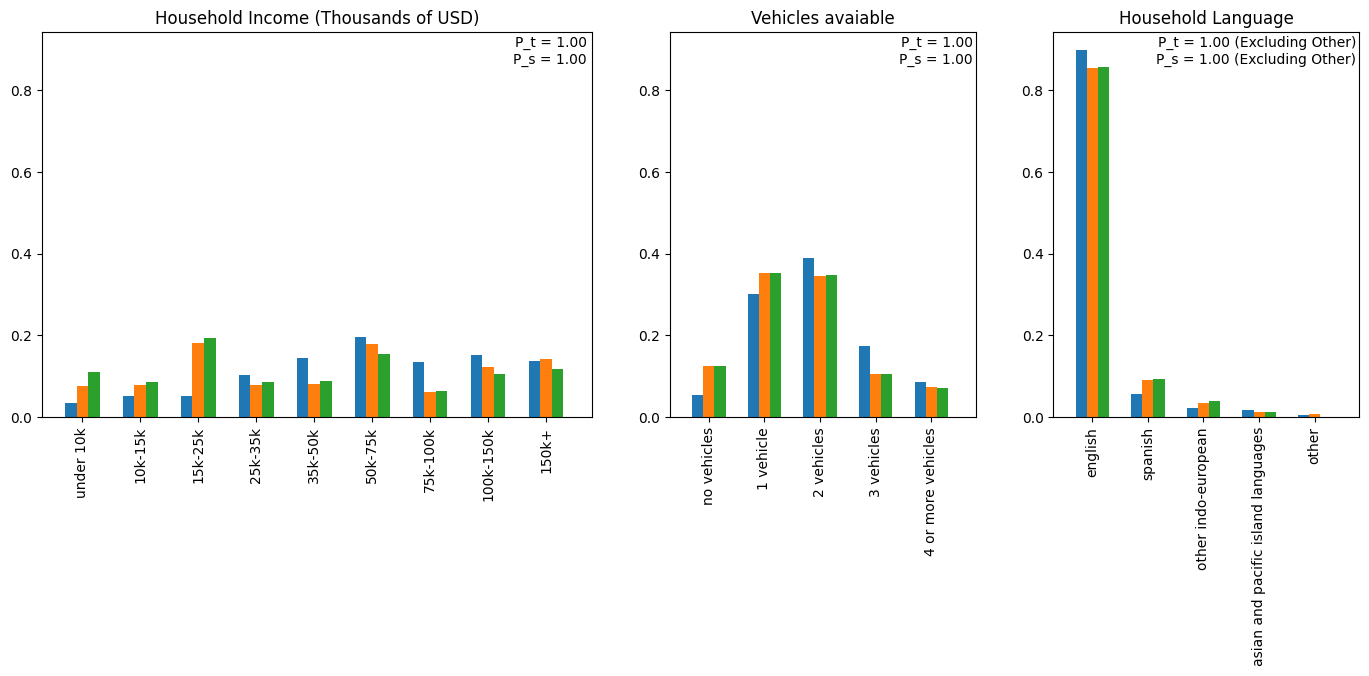

/tmp/ipykernel_46340/2712987911.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


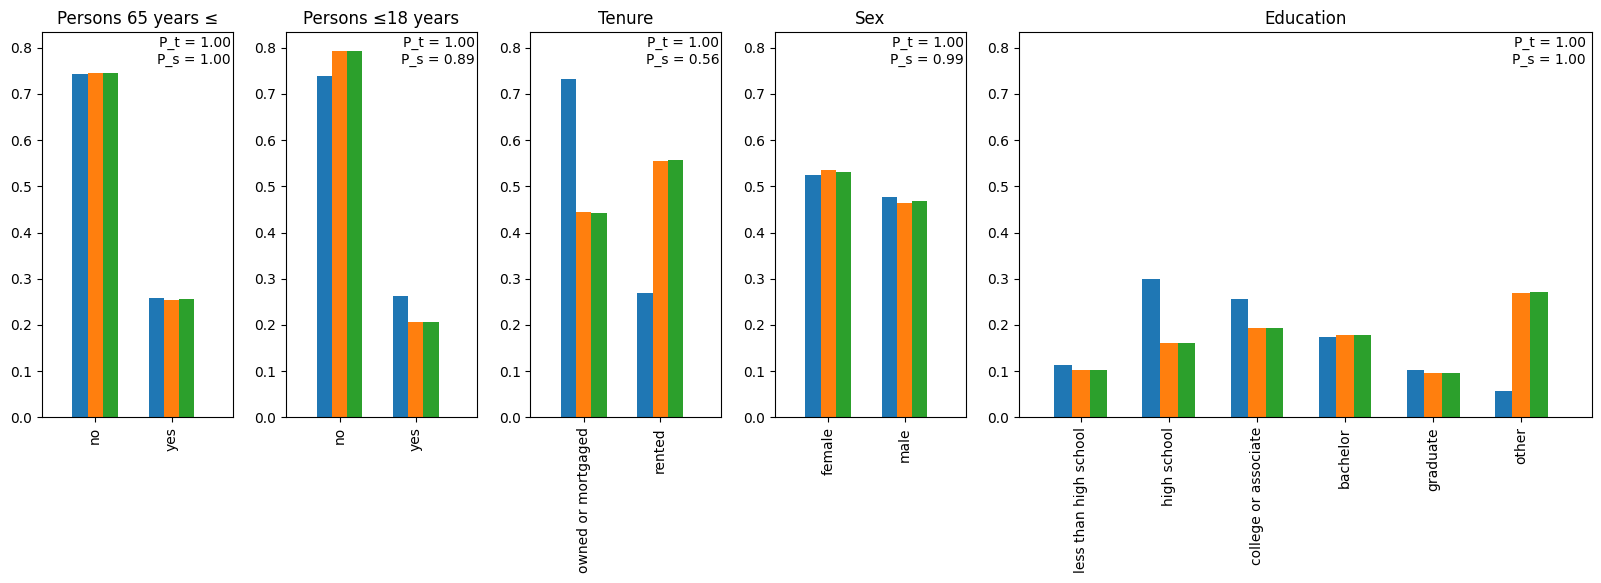

/tmp/ipykernel_46340/2712987911.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


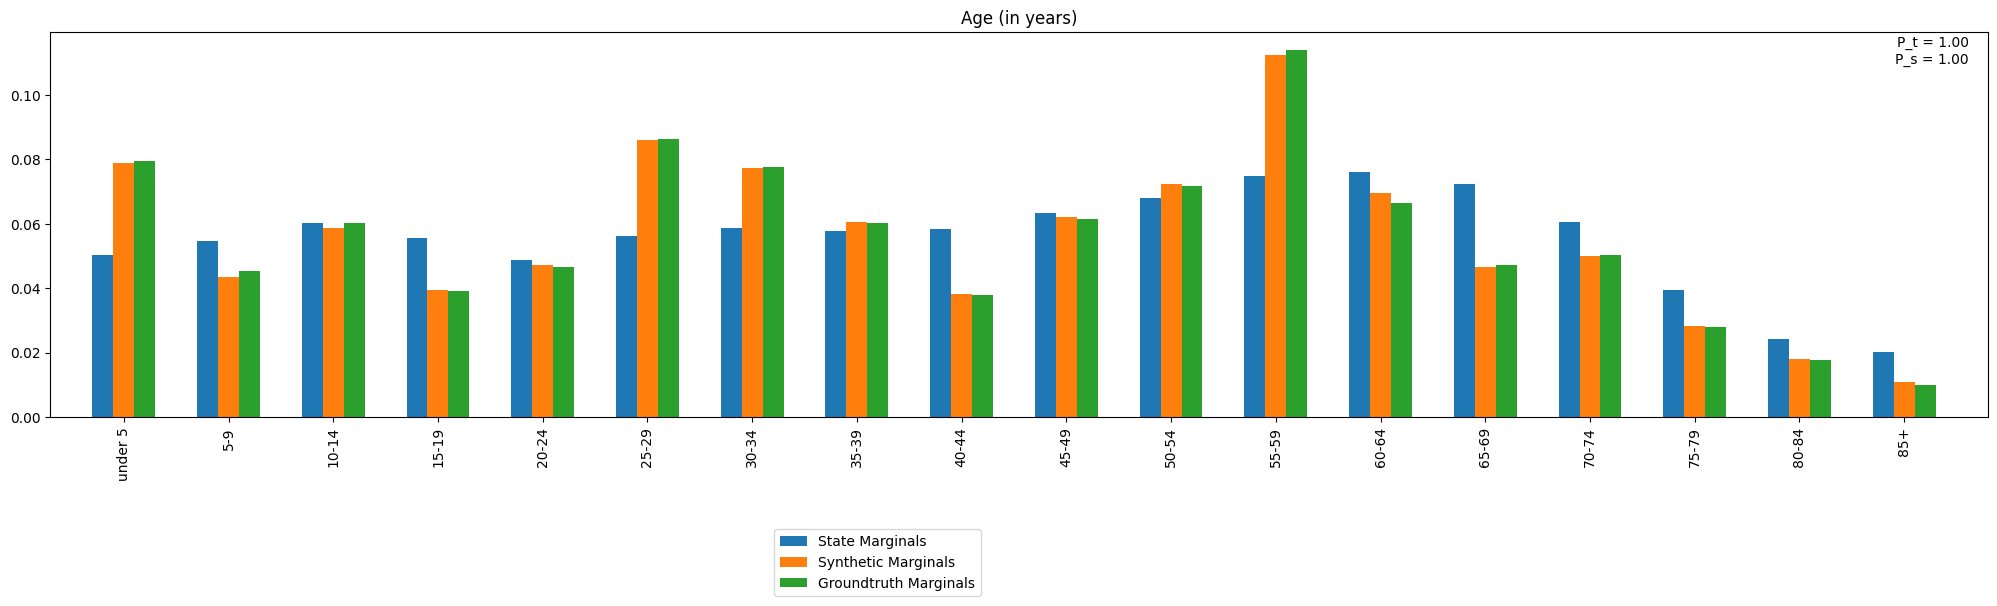

,TEN,VEH,HHL,HINCP,R18,R65,AGEP,SCHL,SEX
RMSE Baseline,0.288343,0.053276,0.031244,0.066434,5.575768e-02,0.002225,0.017606,0.107475,0.008131
RMSE Syn. HI.,0.001561,0.000930,0.004002,0.017804,1.026010e-04,0.001380,0.001126,0.000587,0.003109
KL Baseline,0.170746,0.051862,0.015225,0.180234,8.943147e-03,0.000013,0.046174,0.183742,0.000133
KL Syn. HI.,0.000005,0.000020,0.000377,0.012243,3.214900e-08,0.000005,0.000220,0.000007,0.000019


In [12]:
plot_vars_bars(nc_marginals, predicted_marginals_cheat_nc, state_marginals_nc, ['HINCP', 'VEH', 'HHL'], legend=False, figsize = (17,5), img_name = 'nc_fig10_1_cheat')
plot_vars_bars(nc_marginals, predicted_marginals_cheat_nc, state_marginals_nc, ['R65', 'R18', 'TEN', 'SEX', 'SCHL'], legend=False, figsize = (20,5), img_name = 'nc_fig10_2_cheat')
plot_vars_bars(nc_marginals, predicted_marginals_cheat_nc, state_marginals_nc, ['AGEP'], legend=True, figsize = (25,5), bbox_to_anchor = (0.5, -0.1), img_name = 'nc_fig10_3_cheat')
create_table(nc_marginals, predicted_marginals_cheat_nc, state_marginals_nc, 'nc_table4_cheat')

## Recreate Figure 12


In [23]:
def split_household_and_individual(data):
    # Households are easy
    household_data = data[:, :27]

    # Individuals:
    # Find number of individuals: Extract one of sets of individual variables and see how many there are
    n_individuals = len([k for k in indices.keys() if k.startswith('SEX')])

    # Initialise individuals table
    individual_tables = []

    for i in range(n_individuals):
        # Extract indices corresponding to individual i
        individual_indices = {k:inds for k,inds in indices.items() if k.endswith(f'_{i+1}')}
        individual_indices_flattened = [ind for inds in individual_indices.values() for ind in inds]

        individual_table = data[:,individual_indices_flattened]

        # Append individual 
        individual_tables.append(individual_table)

    individual_data = np.concatenate(individual_tables, axis=0)

    # Clean: Remove individuals with nans
    nan_columns = [2, 21, 28]
    nan_counts = individual_data[:,nan_columns].sum(axis=1)
    individual_data = individual_data[nan_counts==0]

    return household_data, individual_data

def calculate_bces(microdata, synth_data):
    # Ensure inputs are tensors on CUDA
    if not isinstance(microdata, torch.Tensor):
        microdata = torch.tensor(microdata).float()
    if not isinstance(synth_data, torch.Tensor):
        synth_data = torch.tensor(synth_data).float()

    microdata = microdata.to('cuda')
    synth_data = synth_data.to('cuda')

    # Calculate table of all BCEs
    # predictions: (Nt, D) and labels: (N, D)
    Nt, D = synth_data.shape
    eps = 1e-6  # for numerical stability

    # Clamp predictions to avoid log(0)
    synth_data = torch.clamp(synth_data, min=eps, max= 1 - eps)

    # Compute the logarithms
    log_p = torch.log(synth_data)            # (Nt, D)
    log_1_minus_p = torch.log(1 - synth_data)  # (Nt, D)

    # Compute the pairwise BCE using matrix multiplication:
    # First term: (Nt, D) @ (D, N) gives a (Nt, N) matrix.
    term1 = torch.matmul(log_p, microdata.t())
    # Second term: (Nt, D) @ (D, N) for (1-labels)
    term2 = torch.matmul(log_1_minus_p, (1 - microdata).t())
    
    # Combine the terms and average over D.
    # The minus sign is applied as in the BCE formula.
    bce_all = -(term1 + term2) / D  # shape: (Nt, N)

    min_bce = bce_all.min(dim = 1)[0] # Index 0: extract minima, not indices

    return min_bce.cpu().numpy(), bce_all.argmin(dim=1).cpu().numpy()

def get_min_bces(microdata: np.ndarray, synth_data: np.ndarray):
    # Split data into household and individual data
    micro_households, micro_individuals = split_household_and_individual(microdata)
    synth_households, synth_individuals = split_household_and_individual(synth_data)

    # Get minimum BCEs for each and return
    household_bces, household_argmins = calculate_bces(micro_households, synth_households)
    individual_bces, individual_argmins = calculate_bces(micro_individuals, synth_individuals)

    # Find how many exact copies
    ## Household
    micro_households_closest = micro_households[household_argmins]

    if isinstance(synth_households, torch.Tensor):
        synth_households = synth_households.cpu().numpy()
    equal_households = np.all(np.equal(micro_households_closest, synth_households), axis = 1)
    equal_households_count = equal_households.sum()

    ## Individual
    micro_individuals_closest = micro_individuals[individual_argmins]
    equal_individuals = np.all(np.equal(micro_individuals_closest, synth_individuals), axis = 1)
    equal_individuals_count = equal_individuals.sum()

    return household_bces, individual_bces, equal_households_count, equal_individuals_count

def plot_12(household_pretrained,household_finetuned,individual_pretrained,individual_finetuned, img_name = None):
    # Define Bins and Labels
    bins = [0, 0.02, 0.04, 0.06, 0.08, 1]  
    bin_labels = ['<=0.02', '0.04', '0.06', '0.08', '>=0.1']  # For the x-axis

    # Create Histograms

    hh_pre_hist, _ = np.histogram(household_pretrained, bins=bins)
    hh_ft_hist,  _ = np.histogram(household_finetuned, bins=bins)

    ind_pre_hist, _ = np.histogram(individual_pretrained, bins=bins)
    ind_ft_hist,  _ = np.histogram(individual_finetuned, bins=bins)

    # Convert counts to percentages
    hh_pre_hist = hh_pre_hist / hh_pre_hist.sum() * 100
    hh_ft_hist  = hh_ft_hist  / hh_ft_hist.sum()  * 100
    ind_pre_hist = ind_pre_hist / ind_pre_hist.sum() * 100
    ind_ft_hist  = ind_ft_hist  / ind_ft_hist.sum()  * 100

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    # X positions for each bin
    x = np.arange(len(bin_labels))
    width = 0.35

    # Left subplot
    ax1.bar(x - width/2, hh_pre_hist, width, label='Pretrained Model', color='blue')
    ax1.bar(x + width/2, hh_ft_hist,  width, label='Fine-tuned Model', color='orange')

    ax1.set_title('Household Data DCR Values')
    ax1.set_xticks(x)
    ax1.set_xticklabels(bin_labels)
    ax1.set_ylabel('DCR (Percent)')
    ax1.legend()

    # Right subplot
    ax2.bar(x - width/2, ind_pre_hist, width, label='Pretrained Model', color='blue')
    ax2.bar(x + width/2, ind_ft_hist,  width, label='Fine-tuned Model', color='orange')

    ax2.set_title('Individual Data DCR Values')
    ax2.set_xticks(x)
    ax2.set_xticklabels(bin_labels)

    plt.tight_layout()
    if img_name:
        plt.savefig(f'/workspace/finetune_pngs_dfs/{img_name}')
    plt.show()


In [26]:
# Obtain pretrained sample:
from vae import VAE


model = VAE(433, 750, 6, 25, group_sizes)

params = torch.load("/workspace/models/model_l25_h750_b2_g2_y21_final.pth")
model.load_state_dict(params)

synth_data_pretrained = model.pretrain_sample(1436).detach()
hardmax = GroupHardMax(group_sizes) 
synth_data_pretrained_one_hot = hardmax(synth_data_pretrained)

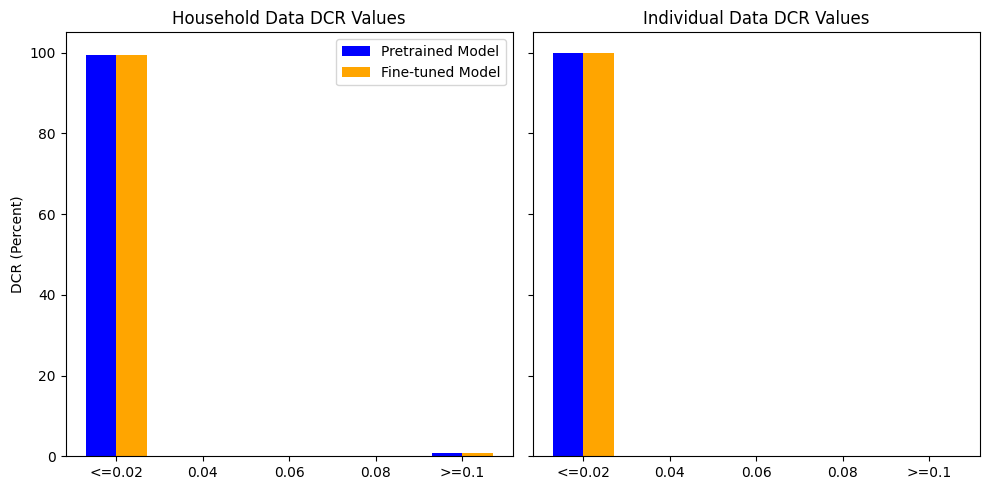

KS Household: 0.9999999997850384
KS Individual: 0.9999999999998351
1418 2695
1430 2939


In [30]:
household_bces_finetuned, individual_bces_finetuned, equal_households_count_finetuned, equal_individuals_count_finetuned = get_min_bces(pums_np, synth_data)
household_bces_pretrained, individual_bces_pretrained, equal_households_count_pretrained, equal_individuals_count_pretrained = get_min_bces(pums_np, synth_data_pretrained_one_hot)
plot_12(household_bces_finetuned, household_bces_finetuned, individual_bces_finetuned, individual_bces_finetuned, img_name = 'privacy.png')
# Kolmogorov Smirnoff test
_, p_KS_household = ks_2samp(household_bces_pretrained, household_bces_finetuned)
_, p_KS_individual = ks_2samp(individual_bces_pretrained, individual_bces_finetuned)

print(f'KS Household: {p_KS_household}\nKS Individual: {p_KS_individual}')
print(equal_households_count_finetuned, equal_individuals_count_finetuned)
print(equal_households_count_pretrained, equal_individuals_count_pretrained)

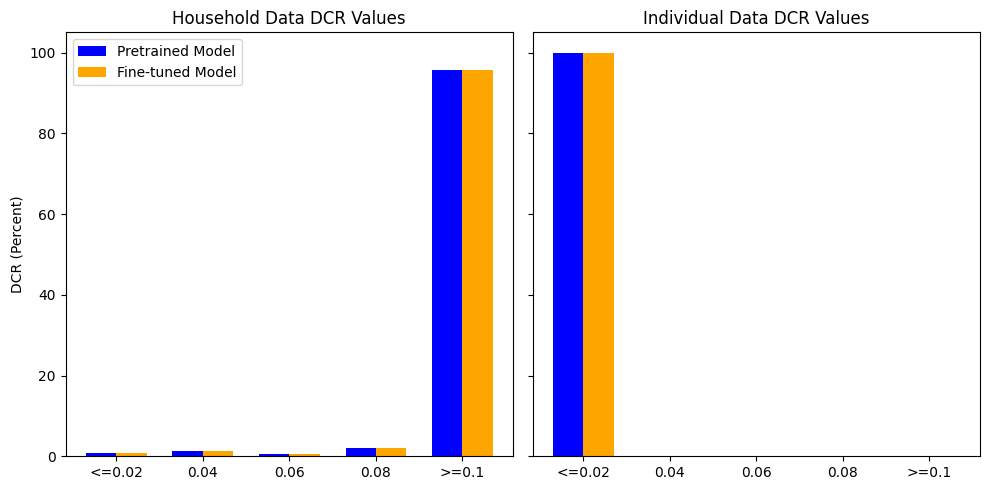

KS Household: 1.276617748721141e-37
KS Individual: 1.0
2 2
2 2


In [29]:
household_bces_finetuned, individual_bces_finetuned, equal_households_count_finetuned, equal_individuals_count_finetuned = get_min_bces(pums_np, predictions_unchanged)
household_bces_pretrained, individual_bces_pretrained, equal_households_count_pretrained, equal_individuals_count_pretrained = get_min_bces(pums_np, synth_data_pretrained)
plot_12(household_bces_finetuned, household_bces_finetuned, individual_bces_finetuned, individual_bces_finetuned, img_name = 'privacy_cheat.png')
# Kolmogorov Smirnoff test
_, p_KS_household = ks_2samp(household_bces_pretrained, household_bces_finetuned)
_, p_KS_individual = ks_2samp(individual_bces_pretrained, individual_bces_finetuned)

print(f'KS Household: {p_KS_household}\nKS Individual: {p_KS_individual}')
print(equal_households_count_finetuned, equal_individuals_count_finetuned)
print(equal_households_count_pretrained, equal_individuals_count_pretrained)

## Discussion results


In [31]:
# Check number of households with R65 but no one over age 65:
# Mask for households with R65: Yes, but no one over age 65
R65_yes_col = r65_dict['yes']
age_groups = ['65-69', '70-74', '75-79', '80-84', '85+']
individuals_over_65_cols = [col for group in age_groups for col in age_dict[group]]

contradiction_mask = (predictions_onehot[:, R65_yes_col] ==1).squeeze() & (predictions_onehot[:, individuals_over_65_cols].sum(axis=1) == 0) 
prop_contradictions = contradiction_mask.sum()/predictions_onehot.shape[0]
print(f' Number of households with R65 yes, but no one over 65: {100*prop_contradictions.item():.2f}%')

 Number of households with R65 yes, but no one over 65: 10.38%


# Explain differences

### Pretrained model choice

In [ ]:
def plot_losses_in_grid(losses, model_names, nrows=2, ncols=2, img_name=None):
    """
    Plots all models' losses in a grid of subplots.
    Only one legend is shown on the far right of the figure.

    Args:
        losses: dict with structure
                {
                  model_name: {
                    loss_type_1: [...loss values...],
                    loss_type_2: [...],
                    ...
                  },
                  ...
                }
        nrows: number of rows of subplots
        ncols: number of columns of subplots
    """

    # Create a figure with a grid of subplots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

    # If you have fewer models than subplots, you may get a 1D or NxM array of axes
    # for convenience, we flatten the axes array:
    # (This also handles the case when nrows=1 and/or ncols=1)
    axes = np.array(axes).ravel()

    # We’ll collect handles/labels from *all* subplots to create a single legend
    all_handles = []
    all_labels = []

    for i, model_name in enumerate(model_names):
        ax = axes[i]

        # For each loss type in this model
        for loss_type, loss_values in losses[model_name].items():
            if loss_type != 'losses':  # skip overall if you want
                loss_values = np.array(loss_values)
                loss_values /= loss_values[0]  # your normalization step
                # Plot on the correct subplot axis
                line, = ax.plot(loss_values, label=loss_type.replace('_', ' '))

        # Build a descriptive title from model_name
        # Example: "DBCE Weight = a, DBCEKL Weights = b, Marginal Loss c"
        a, b, c = model_name.split('_')[-3:]
        ax.set_title(f"DBCE Weight={a}, DBCEKL Weight={b}, Marginal Weight={c}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss Value")

        # Collect legend info from this subplot
        handles, labels = ax.get_legend_handles_labels()
        all_handles.extend(handles)
        all_labels.extend(labels)

    # If there are unused subplots (in case nrows * ncols > n_models), hide them
    for j in range(i+1, nrows*ncols):
        axes[j].set_visible(False)

    # Create a unique set of labels so we don’t get duplicates across subplots
    # (zip them together and convert to a dict so last occurrence of label is taken)
    unique_legend = dict(zip(all_labels, all_handles))
    # Unzip back into lists
    unique_labels = list(unique_legend.keys())
    unique_handles = list(unique_legend.values())

    # Add a single legend to the figure, placing it on the right side
    fig.legend(unique_handles, unique_labels,
               loc='center left',        # position relative to figure’s bounding box
               bbox_to_anchor=(1.1, 0.5) # push legend to the right
               )

    plt.tight_layout()
    if img_name:
        plt.savefig(f'/workspace/finetune_pngs_dfs/{img_name}')
    plt.show()

def plot_npop_losses(losses, model_names, nrows=2, ncols=2, img_name=None):
    """
    Plots all models' losses in a grid of subplots.
    Only one legend is shown on the far right of the figure.

    Args:
        losses: dict with structure
                {
                  model_name: {
                    loss_type_1: [...loss values...],
                    loss_type_2: [...],
                    ...
                  },
                  ...
                }
        nrows: number of rows of subplots
        ncols: number of columns of subplots
    """

    # Create a figure with a grid of subplots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))

    # If you have fewer models than subplots, you may get a 1D or NxM array of axes
    # for convenience, we flatten the axes array:
    # (This also handles the case when nrows=1 and/or ncols=1)
    axes = np.array(axes).ravel()

    # We’ll collect handles/labels from *all* subplots to create a single legend
    all_handles = []
    all_labels = []

    for i, model_name in enumerate(model_names):
        ax = axes[i]

        # For each loss type in this model
        for loss_type, loss_values in losses[model_name].items():
            if loss_type != 'losses':  # skip overall if you want
                loss_values = np.array(loss_values)
                loss_values /= loss_values[0]  # your normalization step
                # Plot on the correct subplot axis
                line, = ax.plot(loss_values, label=loss_type.replace('_', ' '))

        # Build a descriptive title from model_name
        # Example: "DBCE Weight = a, DBCEKL Weights = b, Marginal Loss c"
        n = model_name.split('_')[-1]
        ax.set_title(f"Number of Synthetic Records = {n}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss Value")

        # Collect legend info from this subplot
        handles, labels = ax.get_legend_handles_labels()
        all_handles.extend(handles)
        all_labels.extend(labels)

    # If there are unused subplots (in case nrows * ncols > n_models), hide them
    for j in range(i+1, nrows*ncols):
        axes[j].set_visible(False)

    # Create a unique set of labels so we don’t get duplicates across subplots
    # (zip them together and convert to a dict so last occurrence of label is taken)
    unique_legend = dict(zip(all_labels, all_handles))
    # Unzip back into lists
    unique_labels = list(unique_legend.keys())
    unique_handles = list(unique_legend.values())

    # Add a single legend to the figure, placing it on the right side
    fig.legend(unique_handles, unique_labels,
               loc='center left',        # position relative to figure’s bounding box
               bbox_to_anchor=(1.1, 0.5) # push legend to the right
               )

    plt.tight_layout()
    if img_name:
        plt.savefig(f'/workspace/finetune_pngs_dfs/{img_name}')
    plt.show()

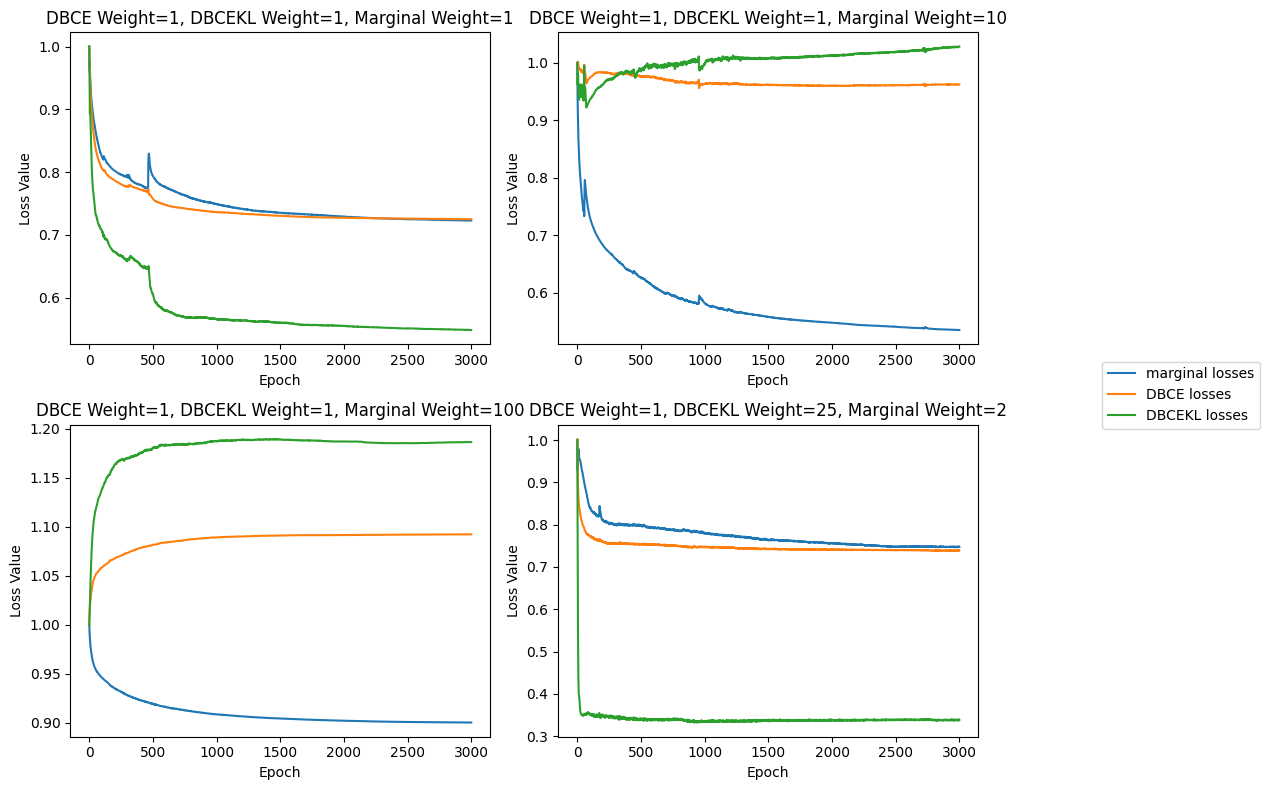

In [ ]:
losses_dir = Path('/workspace/finetuned_models/losses')
losses_jsons = ['finetuned_model_l25_h750_b2_g2_y21_final_1_1_1.json', 
                'finetuned_model_l25_h750_b2_g2_y21_final_1_1_10.json', 
                'finetuned_model_l25_h750_b2_g2_y21_final_1_1_100.json', 
                'finetuned_model_l25_h750_b2_g2_y21_final_1_25_2.json']
model_names = [m.removesuffix('.json') for m in losses_jsons]
delaware_losses = {}
for l in losses_jsons:
    with open(losses_dir / l, 'r') as f:
        delaware_losses[str(l).removesuffix('.json')] = json.load(f)

model_names = [m.removesuffix('.pth') for m in model_names]

plot_losses_in_grid(delaware_losses, model_names, nrows=2, ncols=2, img_name = 'loss_weights_delaware.png')

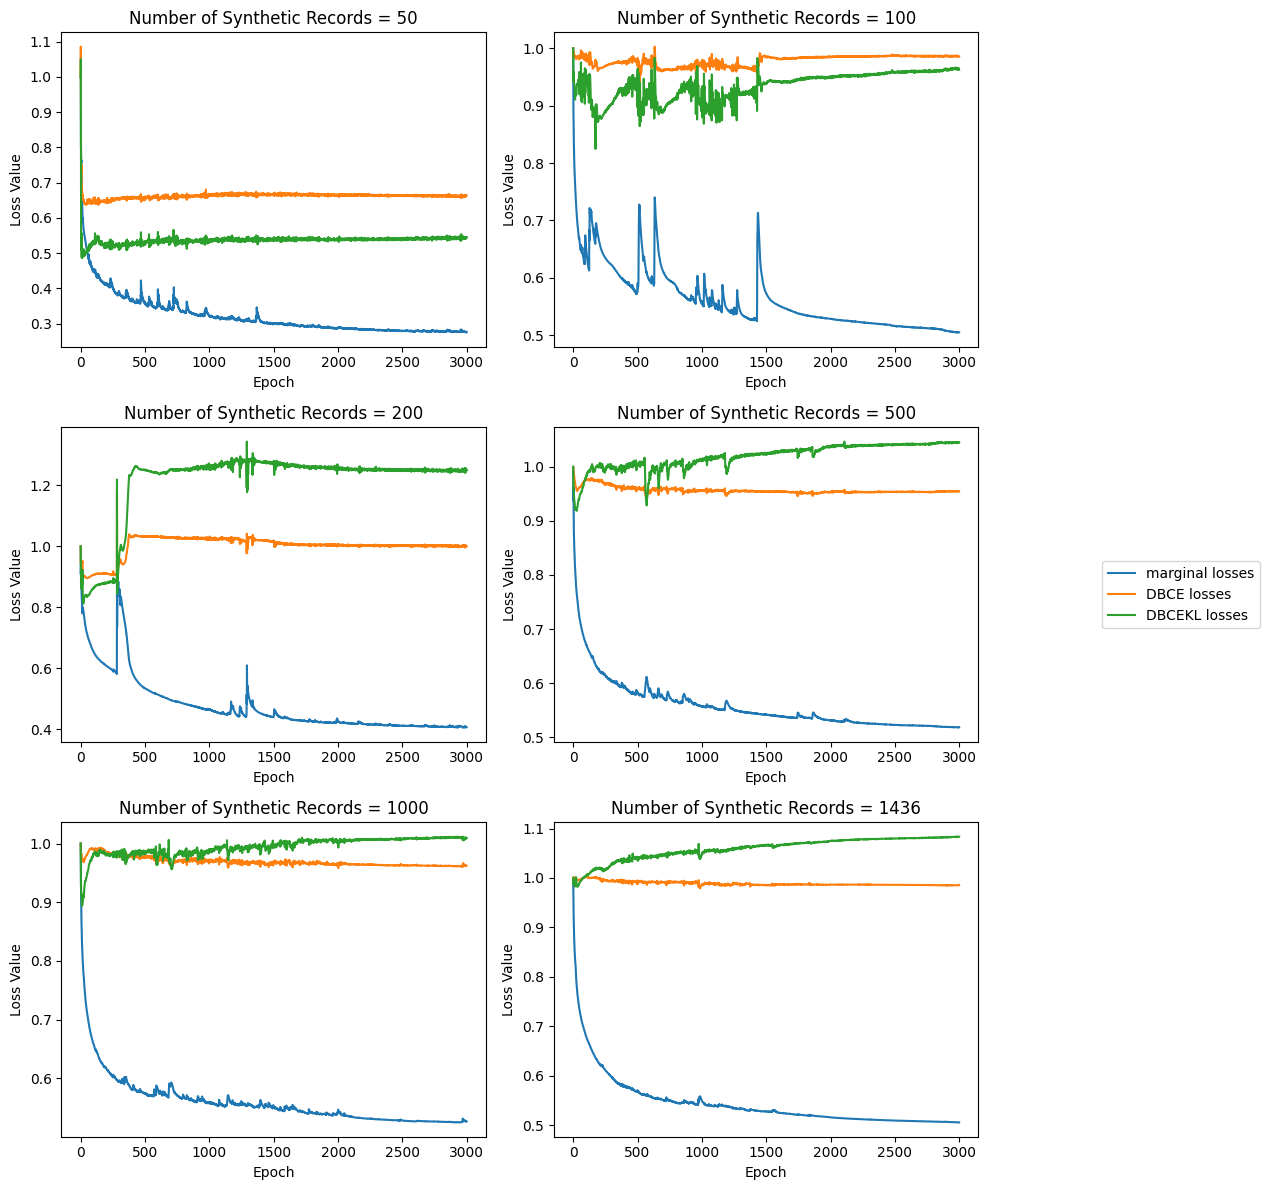

In [ ]:
losses_dir = Path('/workspace/finetuned_models/losses')
losses_jsons = [
    'finetuned_model_l25_h750_b2_g2_y21_final_50.json',
    'finetuned_model_l25_h750_b2_g2_y21_final_100.json',
    'finetuned_model_l25_h750_b2_g2_y21_final_200.json',
    'finetuned_model_l25_h750_b2_g2_y21_final_500.json',
    'finetuned_model_l25_h750_b2_g2_y21_final_1000.json',
    'finetuned_model_l25_h750_b2_g2_y21_final_1436.json'
    ]
n_pop_losses = {}
for l in losses_jsons:
    with open(losses_dir / l, 'r') as f:
        n_pop_losses[l.removesuffix('.json')] = json.load(f)

model_names = [m.removesuffix('.json') for m in losses_jsons]

plot_npop_losses(n_pop_losses, model_names, nrows=3, ncols=2, img_name = 'loss_weights_n_pop.png')
